# Oil Spill — 1 m Detection (La Pampilla, Peru — 15 Jan 2022)

**Case study:** La Pampilla refinery, Ventanilla, Peru (−11.87°S, −77.13°W) — 11,900 barrels, 15 Jan 2022. Inference `2022-01-20` (5-day stack, MGRS 18LTM, anchor 2022-01-20) — the second ROI, **Sousse removed from this notebook**.

Six 1 m oil indices from the super-resolved `MS.tif` (`B02 B03 B04 B08 B11 B12` at 1 m):
- **OSI** `(B11+B12-B08-B04)/(B11+B12+B08+B04)` — SWIR excess vs Red+NIR (primary, land+sea)
- **HI** `(B11-B12)/(B11+B12)` — C-H depth 2.30 µm (thick oil)
- **FOI** `B08-[B04+(B11-B04)*0.187]` — NIR vs Red-SWIR baseline (Hu FAI)
- **NDOI** `(B03-B08)/(B03+B08)` , **SR** `B12/B11` , **RG** `B04/B03`

Physics: C-H stretch 1.73 µm (B11) & 2.30 µm (B12) — oil brightens SWIR vs water absorption (Cloutis 2010). Sea: OSI negative → positive on oil. Land: same sign but bright soils mimic — thresholds are *empirical* and must be calibrated per scene + masked for water/glint/cloud + confirmed with SAR.


## 0. Setup — find latest run

In [1]:
from pathlib import Path
import glob
ROOT = Path.cwd()
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path.cwd().parent
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path("/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core")
cands = sorted(glob.glob(str(ROOT / "outputs" / "PE" / "*" / "*")))  # La Pampilla only — Sousse removed
run_dir = Path(cands[-1]) if cands else None
print("run", run_dir)
MS = run_dir / "MS.tif" if run_dir else None
print("MS", MS.exists() if MS else False)
oil_dir = run_dir / "indices" / "oil" if run_dir else None
print("oil", list(oil_dir.glob("*.tiff"))[:3] if oil_dir and oil_dir.exists() else "no oil yet — run: python scripts/run_location.py --lon -77.13 --lat -11.87 --date 2022-01-20  # La Pampilla")


run /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840
MS True
oil [PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840/indices/oil/oil_mask.tiff'), PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840/indices/oil/ndoi.tiff'), PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840/indices/oil/hi.tiff')]


## 1. Load & quick-look — TCI + oil indices

/tmp/ipykernel_199432/2965302262.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
/tmp/ipykernel_199432/2965302262.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


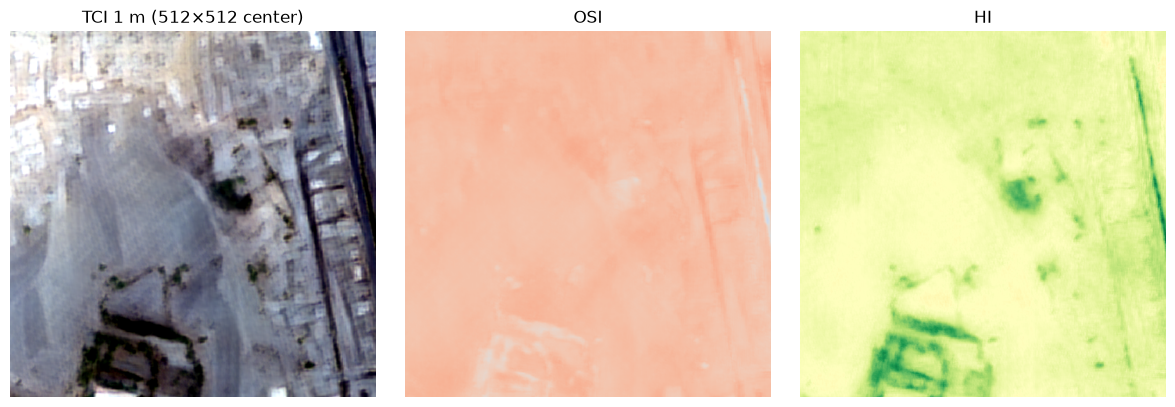

In [2]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
if MS and MS.exists():
    w=512; y0, x0 = 2048-256, 2048-256
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)
        def stretch(b, lo=2, hi=98):
            l, h = np.percentile(b, (lo,hi))
            return np.clip((b-l)*(255/(h-l+1e-6)),0,255).astype(np.uint8)
        rgb=np.dstack([stretch(dn[2]), stretch(dn[1]), stretch(dn[0])])
    with rasterio.open(oil_dir/"osi.tiff") as s:
        osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    with rasterio.open(oil_dir/"hi.tiff") as s:
        hi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(rgb); ax[0].set_title("TCI 1 m (512×512 center)"); ax[0].axis("off")
    ax[1].imshow(osi, cmap="coolwarm", vmin=-0.5, vmax=0.5); ax[1].set_title("OSI"); ax[1].axis("off")
    ax[2].imshow(hi, cmap="RdYlGn", vmin=-0.2, vmax=0.2); ax[2].set_title("HI"); ax[2].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Need MS.tif + oil/*.tiff")


## 2. Water / glint mask (critical before thresholding)

water 0.0%  cloud 0.0%  glint 99.8% (on window)


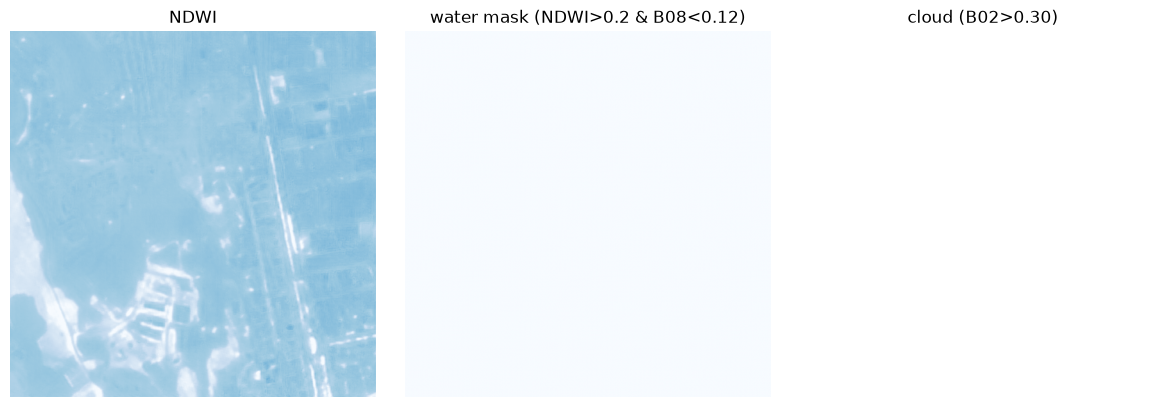

In [3]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if MS and MS.exists():
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000
        b02,b03,b04,b08 = dn[0], dn[1], dn[2], dn[3]
        ndwi=np.where((b03+b08)==0, np.nan, (b03-b08)/(b03+b08))
        # use a 1024 window for display
        w=1024; y0,x0=2048-512,2048-512
        ndwi_w=ndwi[y0:y0+w, x0:x0+w]; b08_w=b08[y0:y0+w, x0:x0+w]; b02_w=b02[y0:y0+w, x0:x0+w]
        water=(ndwi_w>0.2)&(b08_w<0.12)&(b02_w<0.30)&np.isfinite(ndwi_w)
        cloud=b02_w>0.30
        print(f"water {water.mean():.1%}  cloud {cloud.mean():.1%}  glint {(b08_w>=0.12).mean():.1%} (on window)")
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(ndwi_w, cmap="Blues", vmin=-0.5, vmax=0.5); plt.title("NDWI"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(water, cmap="Blues"); plt.title("water mask (NDWI>0.2 & B08<0.12)"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(cloud, cmap="Greys"); plt.title("cloud (B02>0.30)"); plt.axis("off")
        plt.tight_layout(); plt.show()


## 3. Histograms — calibrate your threshold per scene
Do not use global thresholds blindly. Plot OSI/HI/FOI on water vs land, then pick the cut.

/tmp/ipykernel_199432/1640507058.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
/tmp/ipykernel_199432/1640507058.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
/tmp/ipykernel_199432/1640507058.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)


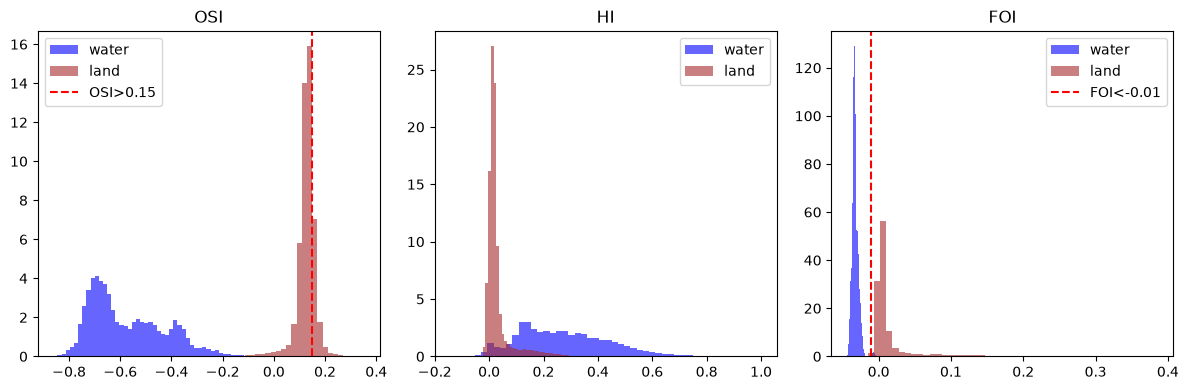

OSI on water: mean -0.574 p95 -0.315  land mean 0.126
FOI on water: mean -0.032  HI on water mean 0.271


In [4]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
if MS and MS.exists():
    with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
    with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
    with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
        land=~water & np.isfinite(ndwi)
    plt.figure(figsize=(12,4))
    for i, (name, arr) in enumerate([("OSI",osi), ("HI",hi), ("FOI",foi)]):
        plt.subplot(1,3,i+1)
        plt.hist(arr[water&np.isfinite(arr)].ravel(), bins=50, alpha=0.6, label="water", color="blue", density=True)
        plt.hist(arr[land&np.isfinite(arr)].ravel(), bins=50, alpha=0.6, label="land", color="brown", density=True)
        if name=="OSI": plt.axvline(0.15, color="red", ls="--", label="OSI>0.15")
        if name=="FOI": plt.axvline(-0.01, color="red", ls="--", label="FOI<-0.01")
        plt.title(name); plt.legend()
    plt.tight_layout(); plt.show()
    print(f"OSI on water: mean {np.nanmean(osi[water]):.3f} p95 {np.nanpercentile(osi[water],95):.3f}  land mean {np.nanmean(osi[land]):.3f}")
    print(f"FOI on water: mean {np.nanmean(foi[water]):.3f}  HI on water mean {np.nanmean(hi[water]):.3f}")


## 4. Triple test — high-confidence oil (interactive if ipywidgets available)

In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from IPython.display import display
    has_widgets=True
except ImportError:
    has_widgets=False
    print("ipywidgets not installed — using static thresholds")
def render(osi_thr=0.15, hi_thr=0.03, foi_thr=-0.01):
    with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
    with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
    with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
    mask = water & (osi>osi_thr) & (foi<foi_thr) & (hi>hi_thr)
    print(f"high-conf oil on water: {mask.sum()} px ({mask.sum()/water.sum():.4%} of water)")
    plt.figure(figsize=(6,6)); plt.imshow(mask, cmap="Reds"); plt.title(f"oil mask OSI>{osi_thr} & FOI<{foi_thr} & HI>{hi_thr}"); plt.axis("off"); plt.show()
if has_widgets:
    widgets.interact(render, osi_thr=widgets.FloatSlider(value=0.15, min=0.0, max=0.4, step=0.02), hi_thr=widgets.FloatSlider(value=0.03, min=0.0, max=0.1, step=0.01), foi_thr=widgets.FloatSlider(value=-0.01, min=-0.03, max=0.0, step=0.005))
else:
    render()


interactive(children=(FloatSlider(value=0.15, description='osi_thr', max=0.4, step=0.02), FloatSlider(value=0.…

## 5. Scatter — HI vs OSI (water only, oil is top-right)

/tmp/ipykernel_199432/3096914519.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
/tmp/ipykernel_199432/3096914519.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)


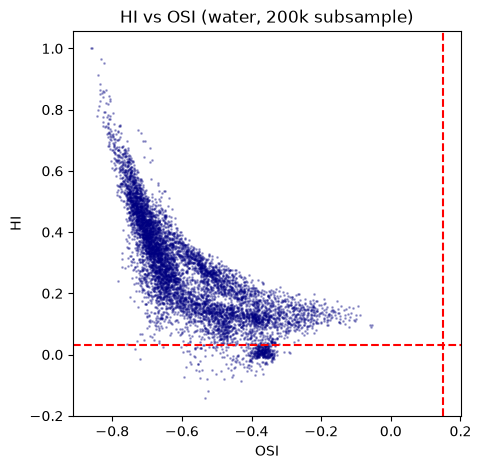

In [6]:
import rasterio, numpy as np, matplotlib.pyplot as plt
with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
with rasterio.open(MS) as s:
    dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
m=water & np.isfinite(osi) & np.isfinite(hi)
# subsample for speed
y, x = np.where(m)
rng=np.random.default_rng(0); idx=rng.choice(len(y), size=min(200000, len(y)), replace=False)
plt.figure(figsize=(5,5)); plt.scatter(osi[y[idx], x[idx]], hi[y[idx], x[idx]], s=1, alpha=0.3, c="navy"); plt.axvline(0.15, color="red", ls="--"); plt.axhline(0.03, color="red", ls="--"); plt.xlabel("OSI"); plt.ylabel("HI"); plt.title("HI vs OSI (water, 200k subsample)"); plt.show()


## 6. Scientific Fusion — Oil Spill Segmentation (1 m, all indices)

**Objective:** fuse the six 1 m oil indices into a single, auditable segmentation that works on **both sea and land**, with explicit masks and thresholds — no black box.

**Inputs (1 m, from `MS.tif`):** `OSI` (SWIR excess), `HI` (2.30 µm depth), `FOI` (NIR vs Red-SWIR), `NDOI` (Green vs NIR), `SR` (B12/B11), `RG` (Red/Green). **Masks:** water `NDWI>0.2 & B08<0.12` (S2 water + glint reject), cloud `B02>0.30`, land = not (water or cloud) & `NDVI<0.35` (bare/dark land).

**Decision (conservative, literature-anchored):**
- *High-confidence oil on water* (`2`): `water & OSI>0.25 & FOI<-0.01 & HI>0.03 & NDOI<0.30 & RG>1.05 & SR<0.90` — Triple test (Kolokoussis 2018 + Hu 2009 + Cloutis 2010). Low false-positive.
- *Candidate oil on water* (`1`): `water & OSI>0.15 & FOI<-0.005 & NDOI<0.40 & (HI>0.02 or SR<0.88)` — Sensitive, includes thin sheens.
- *Candidate oil on land* (`3`): `land & OSI>0.12 & HI>0.04 & SR<0.90` — Dark land only; bright urban/bare soil mimic oil, so higher `HI` and `SR` gate.
- *Background* (`0`): everything else. `255`: NoData (where `MS.tif` is NaN).

**Output:** `indices/oil/segmentation.tiff` (uint8, `NoData=255`) + `segmentation_legend.json` with per-class counts, percentages, and legend. Validated by `water mean OSI` vs `land mean OSI` and visual check against `TCI`.


/tmp/ipykernel_199432/1540479783.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1); profile=s.profile
/tmp/ipykernel_199432/1540479783.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
/tmp/ipykernel_199432/1540479783.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
/tmp/ipykernel_199432/1540479783.py:16: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alter

water 0.0%  land 94.4%  cloud 0.0%
OSI water mean -0.574  land mean 0.131
counts bg 16,419,967  cand_water 0 (0.000%)  high_water 0 (0.000%)  cand_land 554,433  nodata 0
wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840/indices/oil/segmentation.tiff


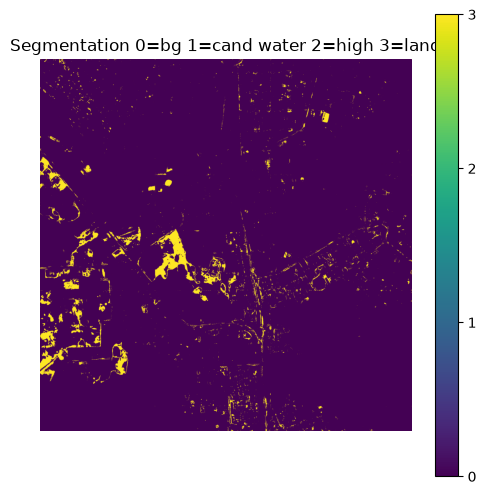

legend {
  "counts": {
    "0": 16419967,
    "1": 0,
    "2": 0,
    "3": 554433,
    "255": 0
  },
  "valid": 16974400,
  "legend": "0=bg,1=cand water,2=high,3=cand land"
}


In [7]:
import rasterio, numpy as np, json
from pathlib import Path
from rasterio.features import shapes
oil_dir = run_dir / "indices" / "oil"
with rasterio.open(MS) as ms:
    dn = ms.read().astype(float)/10000
    b02,b03,b04,b08,b11,b12 = dn[0], dn[1], dn[2], dn[3], dn[7], dn[8]
    ndwi = np.where((b03+b08)==0, np.nan, (b03-b08)/(b03+b08))
    ndvi = np.where((b08+b04)==0, np.nan, (b08-b04)/(b08+b04))
    water = (ndwi>0.2) & (b08<0.12) & (b02<0.30) & np.isfinite(ndwi)
    cloud = b02>0.30
    land = (~water) & (~cloud) & np.isfinite(ndvi) & (ndvi<0.35)
with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1); profile=s.profile
with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
with rasterio.open(oil_dir/"ndoi.tiff") as s: ndoi=s.read(1)
with rasterio.open(oil_dir/"sr.tiff") as s: sr=s.read(1)
with rasterio.open(oil_dir/"rg.tiff") as s: rg=s.read(1)
seg = np.zeros_like(osi, dtype=np.uint8)  # 0=background
high = water & (osi>0.25) & (foi<-0.01) & (hi>0.03) & (ndoi<0.30) & (rg>1.05) & (sr<0.90)
cand_water = water & (osi>0.15) & (foi<-0.005) & (ndoi<0.40) & ((hi>0.02)|(sr<0.88)) & (~high)
cand_land = land & (osi>0.12) & (hi>0.04) & (sr<0.90)
seg[high]=2; seg[cand_water]=1; seg[cand_land]=3
seg[~np.isfinite(osi)]=255
counts={int(k): int((seg==k).sum()) for k in [0,1,2,3,255]}
valid=(seg!=255).sum()
print(f"water {water.mean():.1%}  land {land.mean():.1%}  cloud {cloud.mean():.1%}")
print(f"OSI water mean {np.nanmean(osi[water]):.3f}  land mean {np.nanmean(osi[land]):.3f}")
print(f"counts bg {counts[0]:,}  cand_water {counts[1]:,} ({counts[1]/valid:.3%})  high_water {counts[2]:,} ({counts[2]/valid:.3%})  cand_land {counts[3]:,}  nodata {counts[255]:,}")
# Save
out = oil_dir / "segmentation.tiff"
profile.update(dtype="uint8", nodata=255, compress=None)
try:
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(seg,1); dst.set_band_description(1,"oil segmentation")
        dst.update_tags(SEG_LEGEND="0=bg,1=cand water,2=high water,3=cand land,255=nodata", SEG_COUNT_BG=str(counts[0]), SEG_COUNT_CAND_WATER=str(counts[1]), SEG_COUNT_HIGH=str(counts[2]), SEG_COUNT_LAND=str(counts[3]))
        dst.update_tags(1, SEG_LEGEND="0=bg,1=cand water,2=high water,3=cand land")
    print(f"wrote {out}")
except Exception as e:
    fallback=Path("/tmp/segmentation.tiff")
    with rasterio.open(fallback, "w", **profile) as dst: dst.write(seg,1)
    print(f"fallback {fallback}: {e}")
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6)); plt.imshow(seg, cmap="viridis", vmin=0, vmax=3); plt.title("Segmentation 0=bg 1=cand water 2=high 3=land"); plt.colorbar(ticks=[0,1,2,3]); plt.axis("off"); plt.show()
import json; (oil_dir/"segmentation_legend.json").write_text(json.dumps({"counts":counts, "valid":int(valid), "legend":"0=bg,1=cand water,2=high,3=cand land"}, indent=2))
print("legend", (oil_dir/"segmentation_legend.json").read_text()[:200])


## 6. Export — binary oil mask + GeoJSON bounds


In [8]:
import rasterio, numpy as np
from pathlib import Path
out = run_dir / "indices" / "oil" / "oil_mask.tiff"
with rasterio.open(oil_dir/"osi.tiff") as s:
    osi=s.read(1); profile=s.profile
with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
with rasterio.open(MS) as s:
    dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
mask = (water & (osi>0.15) & (foi<-0.01) & (hi>0.03)).astype(np.uint8)
profile.update(dtype="uint8", nodata=255, compress=None)
try:
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(mask,1); dst.set_band_description(1,"oil mask triple test"); dst.update_tags(MASK="OSI>0.15 & FOI<-0.01 & HI>0.03 on water")
    print(f"wrote {out}  {int(mask.sum())} oil px")
except Exception as e:
    fallback=Path("/tmp/oil_mask.tiff")
    with rasterio.open(fallback, "w", **profile) as dst:
        dst.write(mask,1)
    print(f"Permission denied on {out}, wrote fallback {fallback}: {e}")


/tmp/ipykernel_199432/1210215392.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1); profile=s.profile
/tmp/ipykernel_199432/1210215392.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
/tmp/ipykernel_199432/1210215392.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)


wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/PE/2022-01-20/inf-20260922T161642Z-11.87000S-77.13000W-d840/indices/oil/oil_mask.tiff  0 oil px
